# Simple Tide Elevation Script

the aim of this notebook is to illustrate the use of the Arc2kmTM tidal model, used py pyTMD
and to provide a short, minimalistic example of how to use pyTMD to predict tide elevation
note that if you want to use another of the models supported by pyTMD, you may need to do small changes to the code

.. tip::
    see the `Arc2kmTM_README_v1.pdf` document, `Arc2kmTM`: Model Summary, for units

In [1]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import tide programs
import pyTMD
import timescale

## read dataframe with tide gauge observations

In [2]:

df = pd.read_csv("data_Kartverket_NyAlesund_Juni_2023.txt",
    delimiter=r"\s+",
    parse_dates=["timestamp"],
    comment="#"
)
# convert dates to UTC
df.timestamp = df.timestamp.dt.tz_convert(None)
# convert mean to 0
df.observation -= df.observation.mean()
# parameters for the prediction from file header
lat_to_predict = 78.92589
lon_to_predict = 11.93140
# investigate dataframe
df

,timestamp,observation,astronomical_tide
0,2023-06-30 23:00:00,32.873557,34.8
1,2023-07-01 00:00:00,23.973557,25.3
2,2023-07-01 01:00:00,6.573557,8.6
3,2023-07-01 02:00:00,-12.326443,-10.7
4,2023-07-01 03:00:00,-29.026443,-27.2
...,...,...,...
740,2023-07-31 19:00:00,-33.026443,-39.3
741,2023-07-31 20:00:00,-9.926443,-16.5
742,2023-07-31 21:00:00,17.673557,10.6
743,2023-07-31 22:00:00,42.173557,35.3


In [3]:
# read tide model
model = pyTMD.io.model().from_database("Arc2kmTM")
ds = model.open_dataset(group="z")
# create timescale object from pandas dates
ts = timescale.from_datetime(df.timestamp)

In [4]:
X, Y = ds.tmd.coords_as(lon_to_predict, lat_to_predict, crs=4326)
local = ds.tmd.interp(X, Y, extrapolate=True)
# convert local model to cm
local = local.tmd.to_units('cm')

In [5]:
local

<xarray.Dataset> Size: 96B
Dimensions:     ()
Coordinates:
    x           float64 8B 1.008e+03
    y           float64 8B -656.5
Data variables:
    bathymetry  float64 8B 54.63
    mask        float64 8B 0.7341
    m2          complex64 8B (42.252586-2.5785134j)
    s2          complex64 8B (11.1480665-12.591797j)
    k1          complex64 8B (-2.2547295+7.523694j)
    o1          complex64 8B (-0.94430184-2.0708928j)
    n2          complex64 8B (9.804377+4.2131524j)
    p1          complex64 8B (-0.94957936+2.3632894j)
    k2          complex64 8B (3.0859263-3.9746919j)
    q1          complex64 8B (1.5863134-0.18317369j)
Attributes:
    dt:       0.0
    iob:      []
    bounds:   [-2728.  3666. -4051.  2107.]
    crs:      {'proj': 'stere', 'lat_0': 90, 'lat_ts': 70, 'lon_0': -45, 'x_0...
    group:    z
    format:   OTIS
    source:   Arc2kmTM

In [6]:
# actually perform the prediction
# as long as the location is not changed, this can be used many times to predict for different times
# this is to predict a time series at a single location over many times
tpred = local.tmd.predict(ts.tide, corrections=model.corrections)
tpred += local.tmd.infer(ts.tide, corrections=model.corrections)
# the predicted tides converted to a dataframe
df.insert(2, "tides", tpred.values)

In [7]:
df

,timestamp,observation,tides,astronomical_tide
0,2023-06-30 23:00:00,32.873557,34.095121,34.8
1,2023-07-01 00:00:00,23.973557,24.367781,25.3
2,2023-07-01 01:00:00,6.573557,9.021855,8.6
3,2023-07-01 02:00:00,-12.326443,-7.717308,-10.7
4,2023-07-01 03:00:00,-29.026443,-21.282295,-27.2
...,...,...,...,...
740,2023-07-31 19:00:00,-33.026443,-38.398050,-39.3
741,2023-07-31 20:00:00,-9.926443,-15.213549,-16.5
742,2023-07-31 21:00:00,17.673557,11.459188,10.6
743,2023-07-31 22:00:00,42.173557,35.348378,35.3


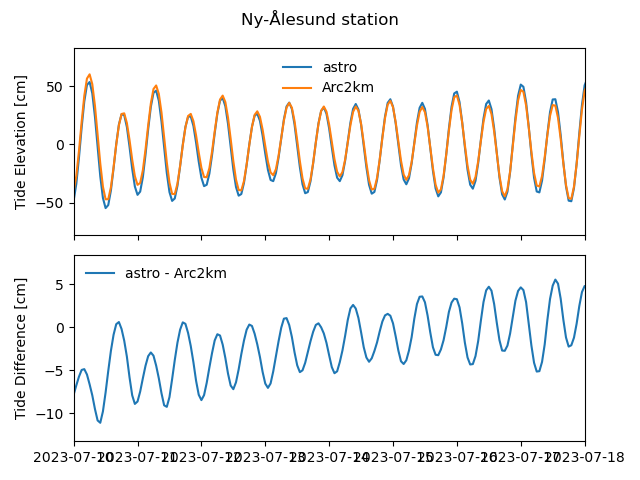

In [8]:
%matplotlib widget
# compare the model data generated by pyTMD to Kartverket astronomical tide computed over a long time series
fig, ax = plt.subplots(nrows=2, sharex=True)
ax[0].plot(df.timestamp, df.astronomical_tide, label='astro')
ax[0].plot(df.timestamp, df.tides, label='Arc2km')
ax[1].plot(df.timestamp, df.astronomical_tide - df.tides, label='astro - Arc2km')
ax[0].set_xlim(datetime.date(2023, 7, 10), datetime.date(2023, 7, 18))
ax[0].legend(frameon=False)
ax[1].legend(frameon=False)
ax[0].set_ylabel("Tide Elevation [cm]")
ax[1].set_ylabel("Tide Difference [cm]")
fig.suptitle("Ny-Ålesund station")
fig.tight_layout()

### success! the comparison is very good - this is a model for the whole Arctic!